# Alouette-2 Data Availability Plot
***

The following script uses

* *ipyml* : for interative figures (optionnal)
* *pandas* : dataframe structure
* *matplotlib* : plot figures
* *numpy* : mathematical operation and multidimensional array
* *datetime* : manipulate time variables 
* *pycountry* : database for the standard countries
* *urllib* : open url
* *PIL* : image and video tool

The flag images are from [twemoji](https://github.com/twitter/twemoji).


## Data Availability

Alouette-2 was a Canadian satellite launched in the 1960s following the success of Alouette-1. Operating for more than a decade, it contributed to ionospheric research and helped advance scientists' understanding of Earth's upper atmosphere. 

The following code helps users vizualise when the ionograms were taken and by which stations. Run all the cells to use the widget *ipympl*.

### Imports

In [11]:
# remove this line if you do not have ipympl
%matplotlib ipympl 

import pandas as pd
import numpy as np
from datetime import datetime as dt
import datetime
import pycountry

import urllib
import PIL
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import dates as mdates
import matplotlib as mpl
from matplotlib.offsetbox import OffsetImage,AnnotationBbox

import warnings
warnings.filterwarnings("ignore")

pd.options.mode.chained_assignment = None  # Remove Setting with copy warning in pandas

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Helper Functions

In [ ]:
# Function to import the corresponding flag images
# Parameters :
# country : Name of the country (string)
def get_flag(country):
    if country=='South Africa':
        url = ('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/'
                'Flag_of_South_Africa_%281982%E2%80%931994%29.svg/'
                '1920px-Flag_of_South_Africa_%281982%E2%80%931994%29.svg.png')
        
    else :
        flagID = {'United States':'1f1fa-1f1f8',
                 'Canada' : '1f1e8-1f1e6',
                 'United Kingdom' : '1f1ec-1f1e7',
                 'Chile' : '1f1e8-1f1f1',
                 'Australia' : '1f1e6-1f1fa',
                 'Ecuador' : '1f1ea-1f1e8',
                 'Spain' : '1f1ea-1f1f8',
                 'Japan' : '1f1ef-1f1f5',
                 'Singapore' : '1f1f8-1f1ec',
                 'Falkland Islands' : '1f1eb-1f1f0',
                 'France' : '1f1eb-1f1f7',
                 'Madagascar' : '1f1f2-1f1ec',
                 'Norway' : '1f1f3-1f1f4',
                 'Peru' : '1f1f5-1f1ea',
                 'Nigeria' : '1f1f3-1f1ec'}
        url = "https://github.com/twitter/twemoji/blob/master/assets/72x72/"+flagID[country]+".png?raw=true"
    
    response = urllib.request.urlopen(url)
    im = np.asarray(PIL.Image.open(response).convert("RGBA"))
    
    return im

# Function to add the flag to the plot
# Parameters :
# coord : Place the add the flag on the y-axis (float)
# country : Name of the country (string)
# ax : Axe with the plot (axe classe)
# startDate : First date on the x-axis (datetime)
def add_image(coord, country, ax, startDate):

    try:
        img = get_flag(country)
    except Exception as e:
        print(f"Could not load flag for {country}: {e}")
        return
    # Get the image
    img = get_flag(country)
    # Adjust the image
    if country=='South Africa':
        z=0.008
    else : z=0.21
    im = OffsetImage(img,zoom=z)
    # Define flag axe
    im.image.axes = ax
    # Add the flag the the plot
    flag = AnnotationBbox(im, (mdates.date2num(startDate), coord),  xybox=(-30., 0.), 
                        frameon=False, xycoords='data',  boxcoords="offset points", pad=0)
    ax.add_artist(flag)

The function above is used to generate the plot. It can be customized by specifying the start and end dates, plot title, stations, metadata type, and colors. By default, the function plots data for all available stations and metadata types.

In [ ]:
# Create the plot for data availability per station
# file : result file with the data
# startDate, endDate : string representing a date YYYYMMDD
# title : title of the plot (string)
# stationCode : list of station you want in the plot (list of string) (default='all')
# metaType : list of meta type you want in the plot (list of string) (default='all')
# cmap : name of the color palette for the plot (string)
def availabilityPlot(data, startDate, endDate, title,
                     stationCode='all', metaType='all',
                     cmap='winter_r'):

    data = data.copy()

    # Keep only valid metadata
    data = data[data['metadata_extracted'] == True]

    # Convert timestamps safely
    data['Timestamp'] = pd.to_datetime(
        data['Timestamp'],
        errors='coerce'
    )

    # Remove invalid timestamps and locations
    data = data.dropna(
        subset=['Timestamp', 'Station_Location']
    )

    startDate = pd.to_datetime(startDate)
    endDate = pd.to_datetime(endDate)

    # Filter dates
    subset = data.loc[
        (data['Timestamp'] >= startDate) &
        (data['Timestamp'] <= endDate)
    ].copy()

    # Filter stations
    if stationCode not in (None, 'all'):
        subset = subset[
            subset['Station_ID'].isin(
                stationCode if isinstance(
                    stationCode,
                    (list, tuple, set)
                )
                else [stationCode]
            )
        ]

    # Filter metadata type
    if metaType != 'all':
        subset = subset[
            subset['processed_image_class'].isin(
                metaType if isinstance(
                    metaType,
                    (list, tuple, set)
                )
                else [metaType]
            )
        ]

    # Keep date only
    subset['Timestamp'] = subset['Timestamp'].dt.normalize()

    # Count records per station
    subset['Station_Frequency'] = (
        subset.groupby('Station_ID')['Station_ID']
        .transform('count')
    )

    # Remove exact duplicates
    subset.drop_duplicates(inplace=True)

    subset.sort_values(
        'Station_Frequency',
        inplace=True,
        ascending=True
    )

    subset.reset_index(
        drop=True,
        inplace=True
    )

    # ==========================================================
    # COVERAGE CALCULATION
    # ==========================================================

    allDates = pd.date_range(
        start=startDate.normalize(),
        end=endDate.normalize(),
        freq='D'
    )

    coveredDates = pd.DatetimeIndex(
        sorted(subset['Timestamp'].unique())
    )

    missingDates = allDates.difference(
        coveredDates
    )

    covered = pd.DataFrame({
        'Timestamp': coveredDates,
        'Availability': 'Days with data'
    })

    notcovered = pd.DataFrame({
        'Timestamp': missingDates,
        'Availability': 'Days without data'
    })

    # ==========================================================
    # FIGURE
    # ==========================================================

    fig, ax = plt.subplots()

    fig.suptitle(title)

    fig.subplots_adjust(
        top=0.93,
        bottom=0.2,
        left=0.3
    )

    # Plot overall availability rows first

    ax.scatter(
        notcovered['Timestamp'],
        notcovered['Availability'],
        marker='|',
        linewidth=0.7,
        color='grey'
    )

    ax.scatter(
        covered['Timestamp'],
        covered['Availability'],
        marker='|',
        linewidth=0.7,
        color='black'
    )

    # ==========================================================
    # STATION PLOT
    # ==========================================================

    plot = ax.scatter(
        subset['Timestamp'],
        subset['Station_Location'],
        c=subset['Station_Frequency'],
        cmap=cmap,
        marker='|',
        linewidth=0.7
    )

    cax = fig.add_axes(
        [0.34, 0.067, 0.5, 0.03]
    )

    cbar = fig.colorbar(
        plot,
        cax=cax,
        orientation='horizontal'
    )

    cbar.set_label(
        'Number of ionograms between '
        + startDate.strftime('%Y-%m-%d')
        + ' and '
        + endDate.strftime('%Y-%m-%d')
    )

    stationName = pd.DataFrame()

    stationName['Station_Location'] = (
        subset['Station_Location']
    )

    stationName['Country'] = (
        subset['Country']
    )

    stationName.drop_duplicates(
        inplace=True,
        ignore_index=True
    )

    plt.draw()

    labels = [
        tick.get_text()
        for tick in ax.get_yticklabels()
    ]

    for _, row in stationName.iterrows():

        station = row['Station_Location']
        country = row['Country']

        if pd.isna(country) or country == '':
            continue

        try:
            y = labels.index(station)

            add_image(
                y,
                country,
                ax,
                startDate
            )

        except Exception as e:
            print(
                f"Skipping flag for {country}: {e}"
            )

    # ==========================================================
    # GRID
    # ==========================================================

    ax.grid(
        which='major',
        axis='x',
        alpha=0.7,
        lw=0.7,
        ls='-'
    )

    ax.grid(
        which='minor',
        axis='x',
        alpha=0.7,
        lw=0.5,
        ls='--'
    )

    ax.tick_params(
        which='major',
        axis='x',
        labelrotation=90
    )

    ax.tick_params(
        which='major',
        axis='y',
        pad=26
    )

    # ==========================================================
    # COVERAGE STAT
    # ==========================================================

    nbdays = int(
        (endDate - startDate).days + 1
    )

    per = (
        len(coveredDates)
        / nbdays
        * 100
    )

    fig.text(
        0.13,
        0.075,
        f'% of days with data : {per:.2f}%',
        va='bottom',
        bbox=dict(
            boxstyle='round,pad=0.5',
            alpha=0.5
        )
    )

    # ==========================================================
    # X AXIS
    # ==========================================================

    interval = (
        (endDate.year - startDate.year) * 12
        + (endDate.month - startDate.month)
    )

    if interval <= 6:

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='W'
            )
        )

    elif interval <= 18:

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='MS'
            )
        )

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='SMS'
            ),
            minor=True
        )

    elif interval <= 36:

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='2MS'
            )
        )

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='MS'
            ),
            minor=True
        )

    elif interval <= 60:

        xmajor = pd.date_range(
            startDate,
            endDate,
            freq='4MS'
        )

        ax.set_xticks(xmajor)

        ax.set_xticklabels(
            xmajor.strftime('%Y-%m')
        )

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='2MS'
            ),
            minor=True
        )

    else:

        xmajor = pd.date_range(
            str(startDate.year) + '0701',
            str(endDate.year) + '0701',
            freq='6MS'
        )

        ax.set_xticks(xmajor)

        ax.set_xticklabels(
            xmajor.strftime('%Y-%m')
        )

        ax.set_xticks(
            pd.date_range(
                startDate,
                endDate,
                freq='QS'
            ),
            minor=True
        )

    return fig

Display flags on the plot by adding a 'Country' column to the dataFrame, specifying the country associated to each country. 

In [14]:
df = pd.read_csv(
    Path(
        r'L:\DATA\ISIS\Imageupload_20260428_Processing\05_Imageupload_20260428_metadata_satellite_number_adjusted.csv',
    ),
    encoding="cp1252",
    usecols=['Timestamp','Station_ID','Station_Location','processed_image_class', 'metadata_extracted']
    )

In [15]:
# Clean station locations
df['Station_Location'] = (
    df['Station_Location']
    .astype(str)
    .str.replace('Â', '', regex=False)
    .str.replace('\xa0', '', regex=False)
    .str.strip()
)

# Create a list of stations
stationList = df['Station_Location'].unique().tolist()


# Create a list of stations
stationList = df['Station_Location'].unique().tolist()

# Create empty list
countries = []

# Determine country for each station
for station in stationList:

    country_found = None

    if isinstance(station, str):

        # Manual exceptions
        if 'Florida' in station:
            country_found = 'United States'

        elif 'Maryland' in station:
            country_found = 'United States'

        elif 'England' in station or 'UK' in station:
            country_found = 'United Kingdom'

        elif 'Antartica' in station:
            country_found = 'United States'

        elif 'Guam' in station:
            country_found = 'United States'

        elif 'Falkland Islands' in station:
            country_found = 'Falkland Islands'

        else:
            for country in pycountry.countries:
                if country.name in station or country.alpha_3 in station:
                    country_found = country.name

                    # Fix Niger/Nigeria confusion
                    if country_found == 'Niger' and 'Nigeria' in station:
                        country_found = 'Nigeria'

                    break

    countries.append(country_found)

# Create Country column
station_country = dict(zip(stationList, countries))

df['Country'] = df['Station_Location'].map(station_country)

# Check result
print(df[['Station_Location', 'Country']].drop_duplicates())

df.head()

                      Station_Location         Country
0                                  NaN             NaN
1                       Quito, Ecuador         Ecuador
238                Fort Myers, Florida   United States
292                  Darwin, Australia       Australia
1817                    Tromso, Norway          Norway
2439           Terre Adelie, Antartica   United States
7551          Kerguelen Island, France          France
7711           Blossom Point, Maryland   United States
8123                   Santiago, Chile           Chile
8209               Lauder, New Zealand     New Zealand
8217             Prince Albert, Canada          Canada
9297                    Kashima, Japan           Japan
9323              Ascension Island, UK  United Kingdom
12724                    Kano, Nigeria         Nigeria
12987                       Lima, Peru            Peru
14635                             Guam   United States
15389                 Chilton, England  United Kingdom
17844  Las

,processed_image_class,metadata_extracted,Timestamp,Station_Location,Station_ID,Country
0,loss,False,NaN,NaN,NaN,NaN
1,num2,True,6/24/1966 14:05:28,"Quito, Ecuador",QUI,Ecuador
2,num2,True,6/24/1966 14:06:01,"Quito, Ecuador",QUI,Ecuador
3,num2,True,6/24/1966 14:06:33,"Quito, Ecuador",QUI,Ecuador
4,num2,True,6/24/1966 14:07:06,"Quito, Ecuador",QUI,Ecuador


Metadata types and station codes can be entered as availability plot parameters.

#### Metadata types
* dot : dots on the side of ionograms
* num : numbers on the side of ionograms
* num2 : numbers at the bottom of ionograms

#### Stations
| **Station Code** | Station Name | **Station Code** | Station Name |**Station Code** | Station Name |
|:-------------|:-------------|:-------------|:-------------|:-------------|:-------------|
|**ANT**|Antofagasta, Chile|**JOB**|Johannesburg, South Africa|**RAL**|Orroral Valley, Australia|
|**BAT**|Byrd Station, Antarctica|**KJP**|Kashima, Japan|**RES**|Resolute Bay, NT, Canada|
|**BFR**|Bretigny, France|**KNO**|Kano, Nigeria|**ROS**|Rosman, NC, USA|
|**BLR**|Boulder, CO, USA|**LIM**|Lima, Peru|**SNP**|Singapore|
|**BPT**|Blossom Point, MD, USA|**MAD**|Tananarive, Madagascar|**SNT**|Santiago, Chile|
|**COL**|College, Fairbanks, AK, USA|**MOJ**|Mojave, CA, USA|**SOL**|Falkland Islands (Islas Malvinas)|
|**DAR**|Darwin, Australia|**NEW**|St. John's, NL, Canada|**SPT**|South Point, HI, USA|
|**FTM**|Fort Myers, FL, USA|**OTT**|Ottawa, Canada|**TRO**|Tromso, Norway|
|**GIL**|Gilmore Creek, Fairbanks, AK, USA|**PCI**|Las Palmas, Canary Islands, Spain|**ULA**|University of Alaska, Fairbanks, AK, USA|
|**GRK**|East Grant Forks, MN, USA|**PRI**|Prince Albert, SK, Canada|**WNK**|Winkfield, England, UK|
|**HAW**|Kauai, HI, USA|**QUI**|Quito, Ecuador|**WOO**|Woomera, Australia|

You may also customize the plot's colour palette by selecting a *matplotlib* colour map [here](https://matplotlib.org/stable/tutorials/colors/colormaps.html) or by creating your own. The default plot uses *winter_r*. 

In [16]:
# this code makes the colours go from red to purple
colors = ['red','purple','#3d226d']
redpurple = LinearSegmentedColormap.from_list("mycmap", colors)

You can further customize the plot using *Matplotlib* parameters.

In [17]:
mpl.rcParams['font.family']='Arial' #The font for the whole figure
mpl.rcParams['figure.titlesize']=14 #The title
mpl.rcParams['axes.labelsize']=10 #Title of colorbar axis and plot axis 
                                  #(there is no title for the y-axis and x-axis at the moment)
mpl.rcParams['font.size']=8 #Size of text in box
mpl.rcParams['xtick.labelsize']=10 #Size of the dates on the x-axis and the numbers of the colorbar
mpl.rcParams['xtick.major.size']=6 #Size of major tick lines on the x-axis
mpl.rcParams['xtick.minor.size']=3 #Size of major tick lines on the x-axis
mpl.rcParams['ytick.labelsize']=10 #Size of the station names on the y-axis
mpl.rcParams['ytick.major.size']=6 #Size of tick lines on the y-axis
mpl.rcParams['figure.figsize']=(10,9) #width, height of figure 
                                      #(10 x 9 was the best to display in Jupyter Notebook, 
                                      #but it could be bigger if saved on the computer)

## Plot Data Availability

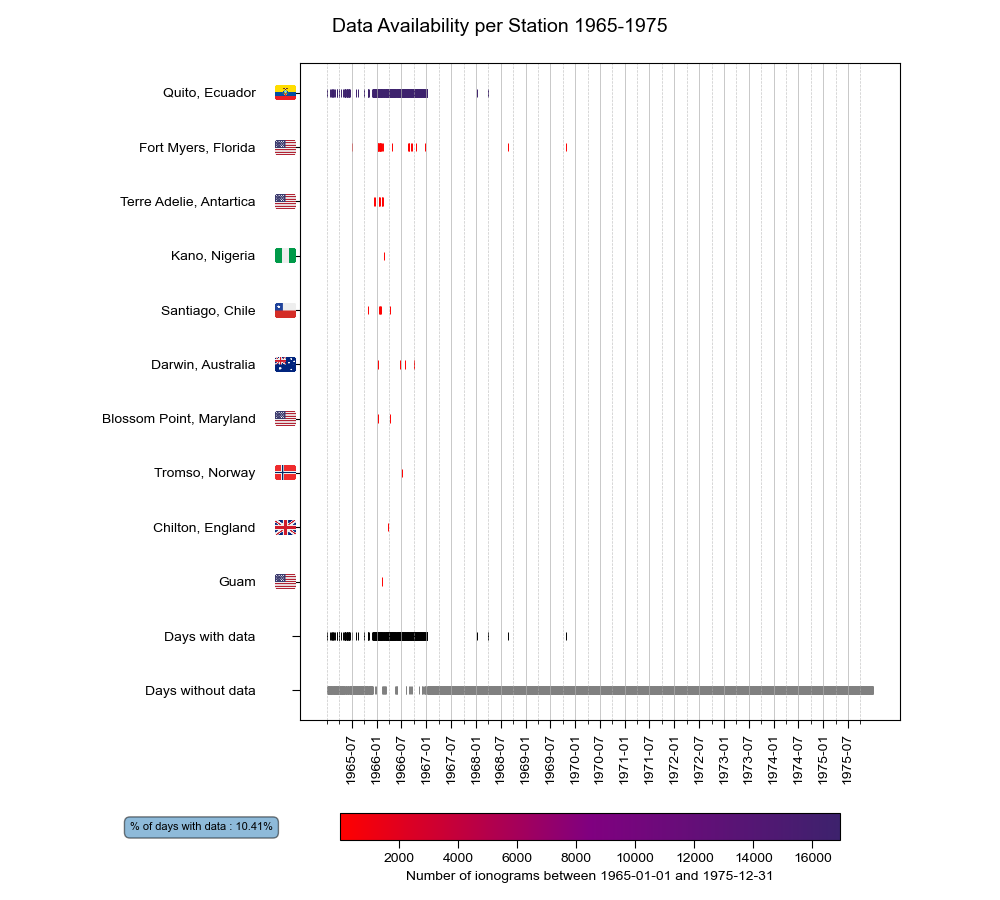

In [ ]:
fig_save_path = ''

fig = availabilityPlot(df,
                       '19650101','19751231','Data Availability per Station 1965-1975',
                       cmap=redpurple)

if fig_save_path:
    plt.savefig(fig_save_path)

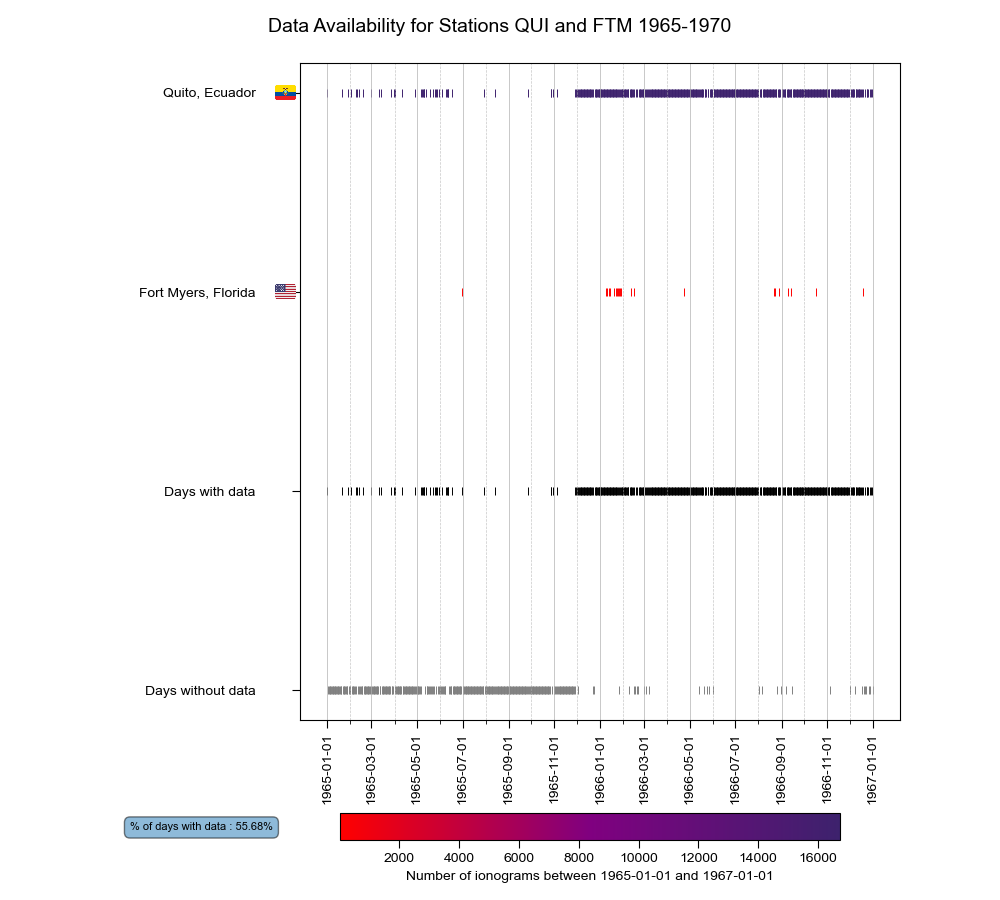

In [ ]:
fig_save_path = ''


fig = availabilityPlot(df,
                       '19650101','19670101','Data Availability for Stations QUI and FTM 1965-1970',
                       cmap=redpurple, 
                       stationCode=['QUI', 'FTM'])

if fig_save_path:
    plt.savefig(fig_save_path)